<a href="https://colab.research.google.com/github/sayidbek-bakhrom/Red-Wine-Quality/blob/main/Predicting_Red_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍷 Red Wine Quality

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, \
AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
# from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset

In [ ]:
df = pd.read_csv('/content/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.shape

(1599, 12)

In [ ]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

# 2. Data Statistics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


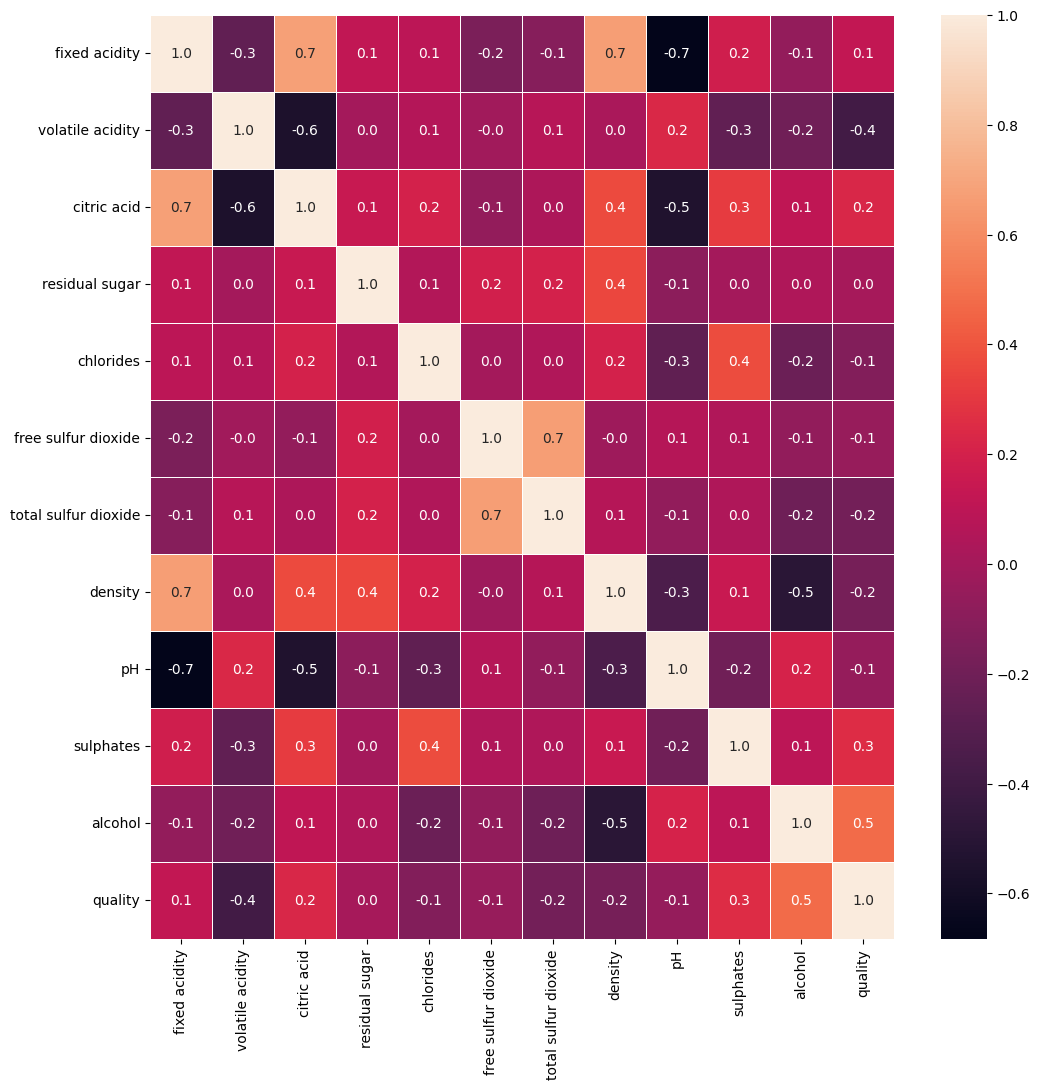

In [ ]:
# correlation map
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt='.1f', ax=ax)
# sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt='.1f', ax=ax, mask=np.triu(df.corr()))
plt.show()

**Observation:**

The dataset contains a total of 1599 rows and 12 columns, where there are 11 features and 1 label.
All values in the dataset are non-null and numerical.
The target variable is represented by the column: quality.

# 3. Data Visualization

In [ ]:
features = df.columns[:-1].values
label = df.columns[-1]

print('The features are:', features)
print('The label is:', label)

The features are: ['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates' 'alcohol']
The label is: quality


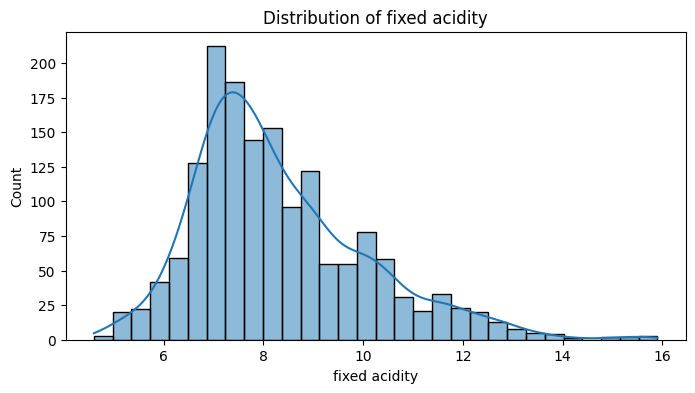

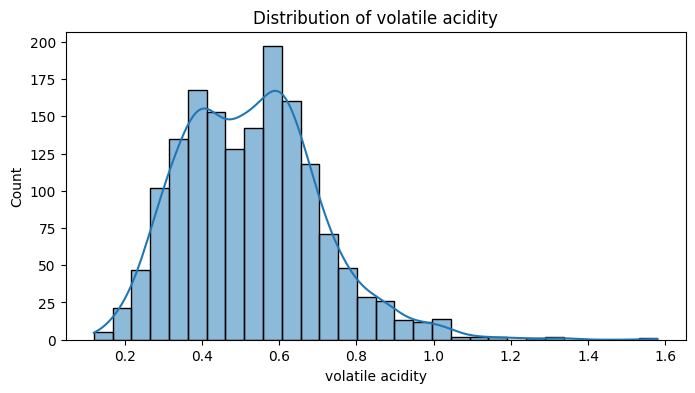

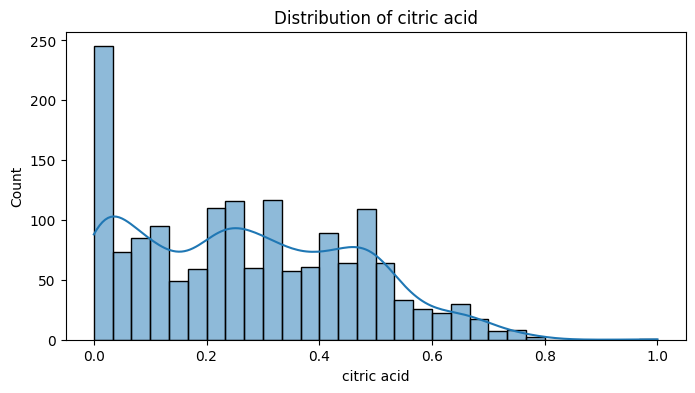

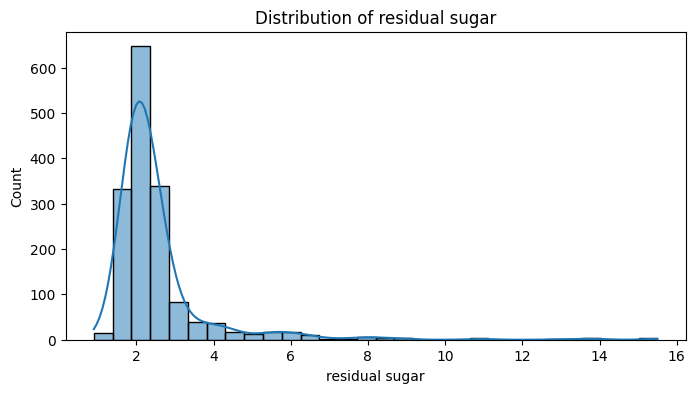

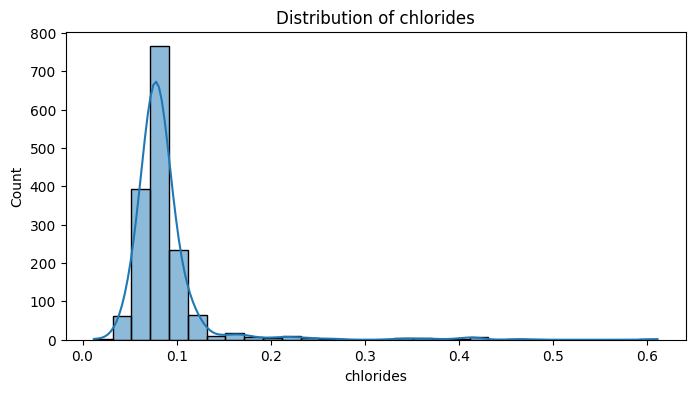

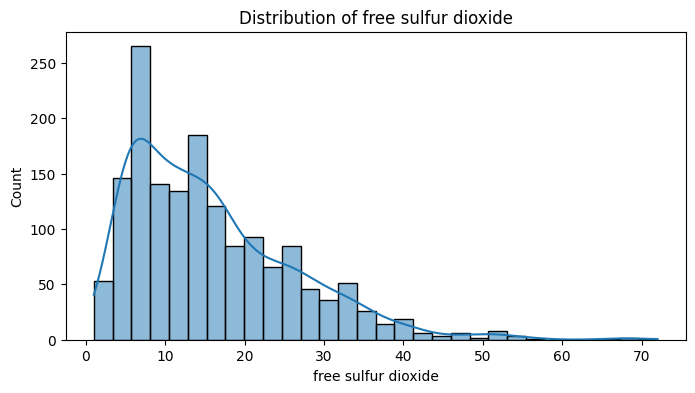

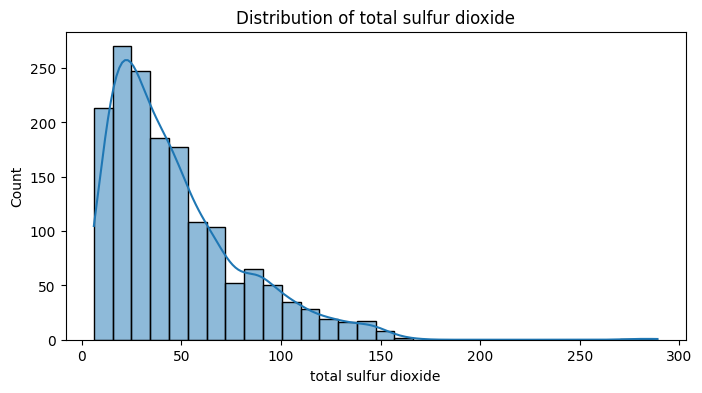

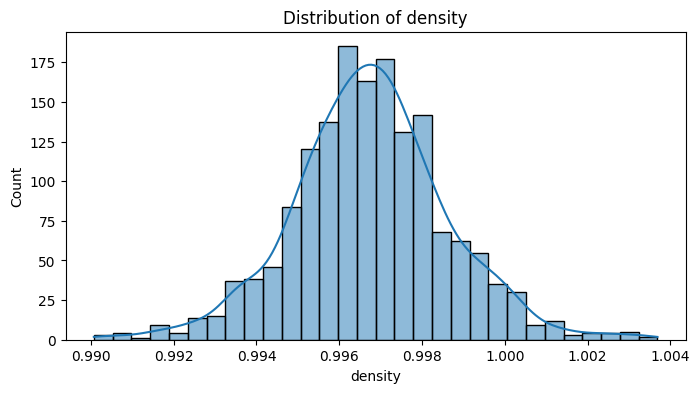

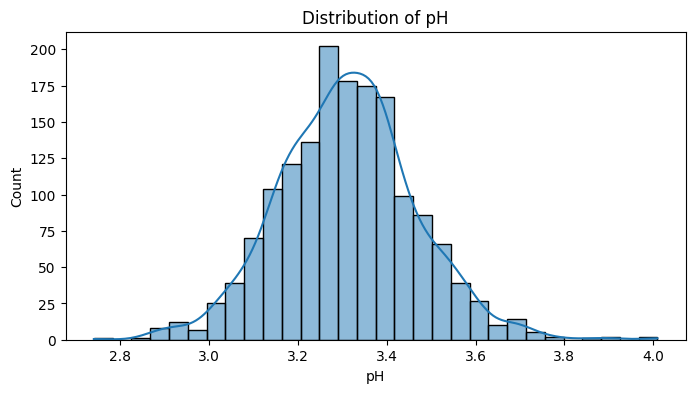

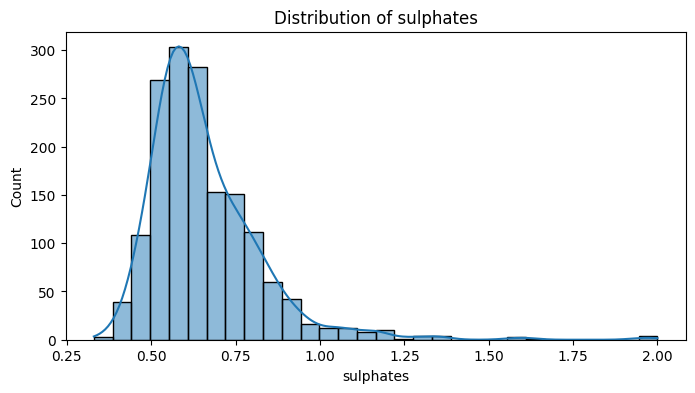

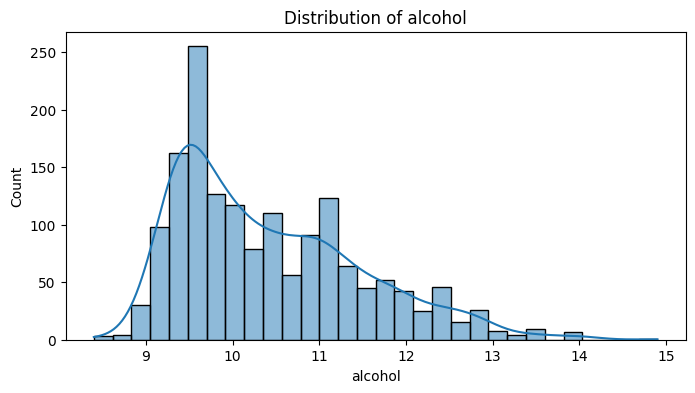

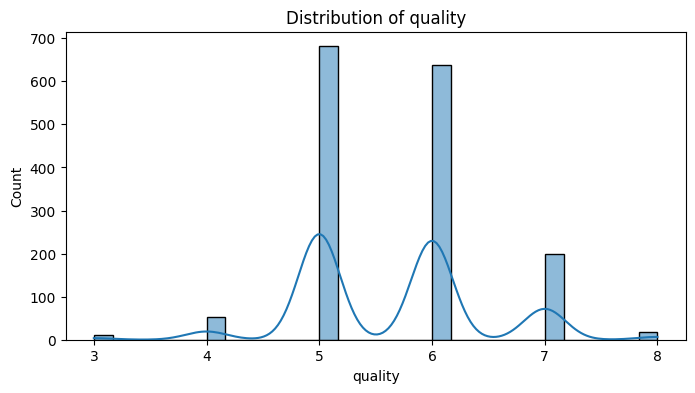

In [ ]:
# plot histogram for each column
for column in df:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.show()

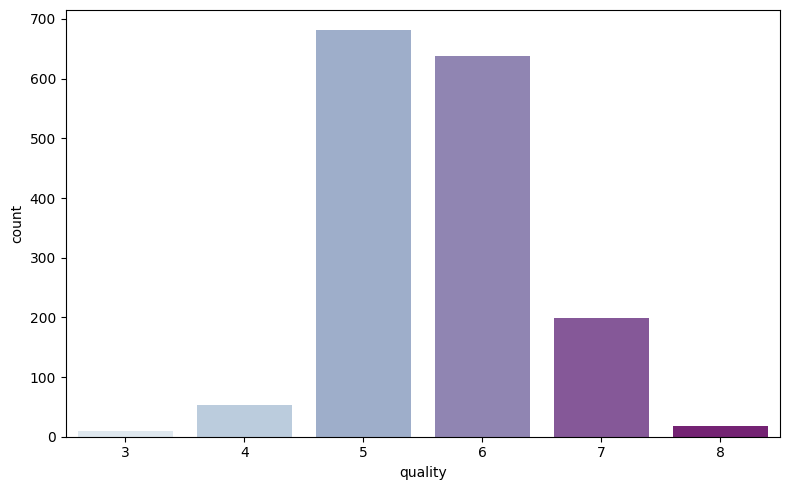

In [ ]:
# set custom labels
labels = ['3', '4', '5', '6', '7', '8']
ticks = range(len(labels))

# create a figure
fig, ax = plt.subplots(figsize=(8, 5))

# plot the count plot

sns.countplot(data=df, x='quality', ax=ax, palette=sns.color_palette('BuPu'))
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

# adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

In [ ]:
df.columns.values

array(['fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'], dtype=object)

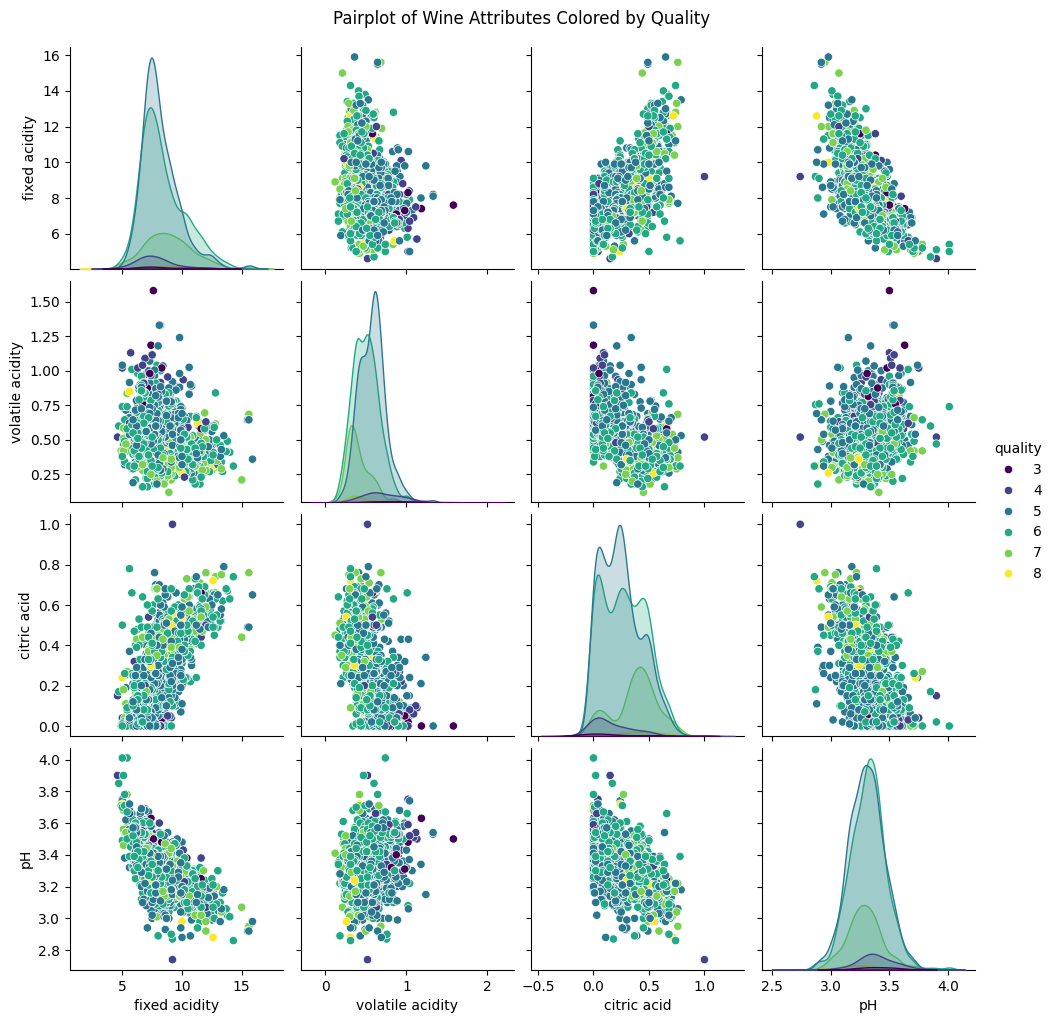

In [ ]:
acid_attributes = ['fixed acidity','volatile acidity', 'citric acid', 'pH', 'quality']
pairplot = sns.pairplot(df[acid_attributes], hue='quality', palette='viridis')

pairplot.fig.suptitle('Pairplot of Wine Attributes Colored by Quality', y=1.02)
plt.show()

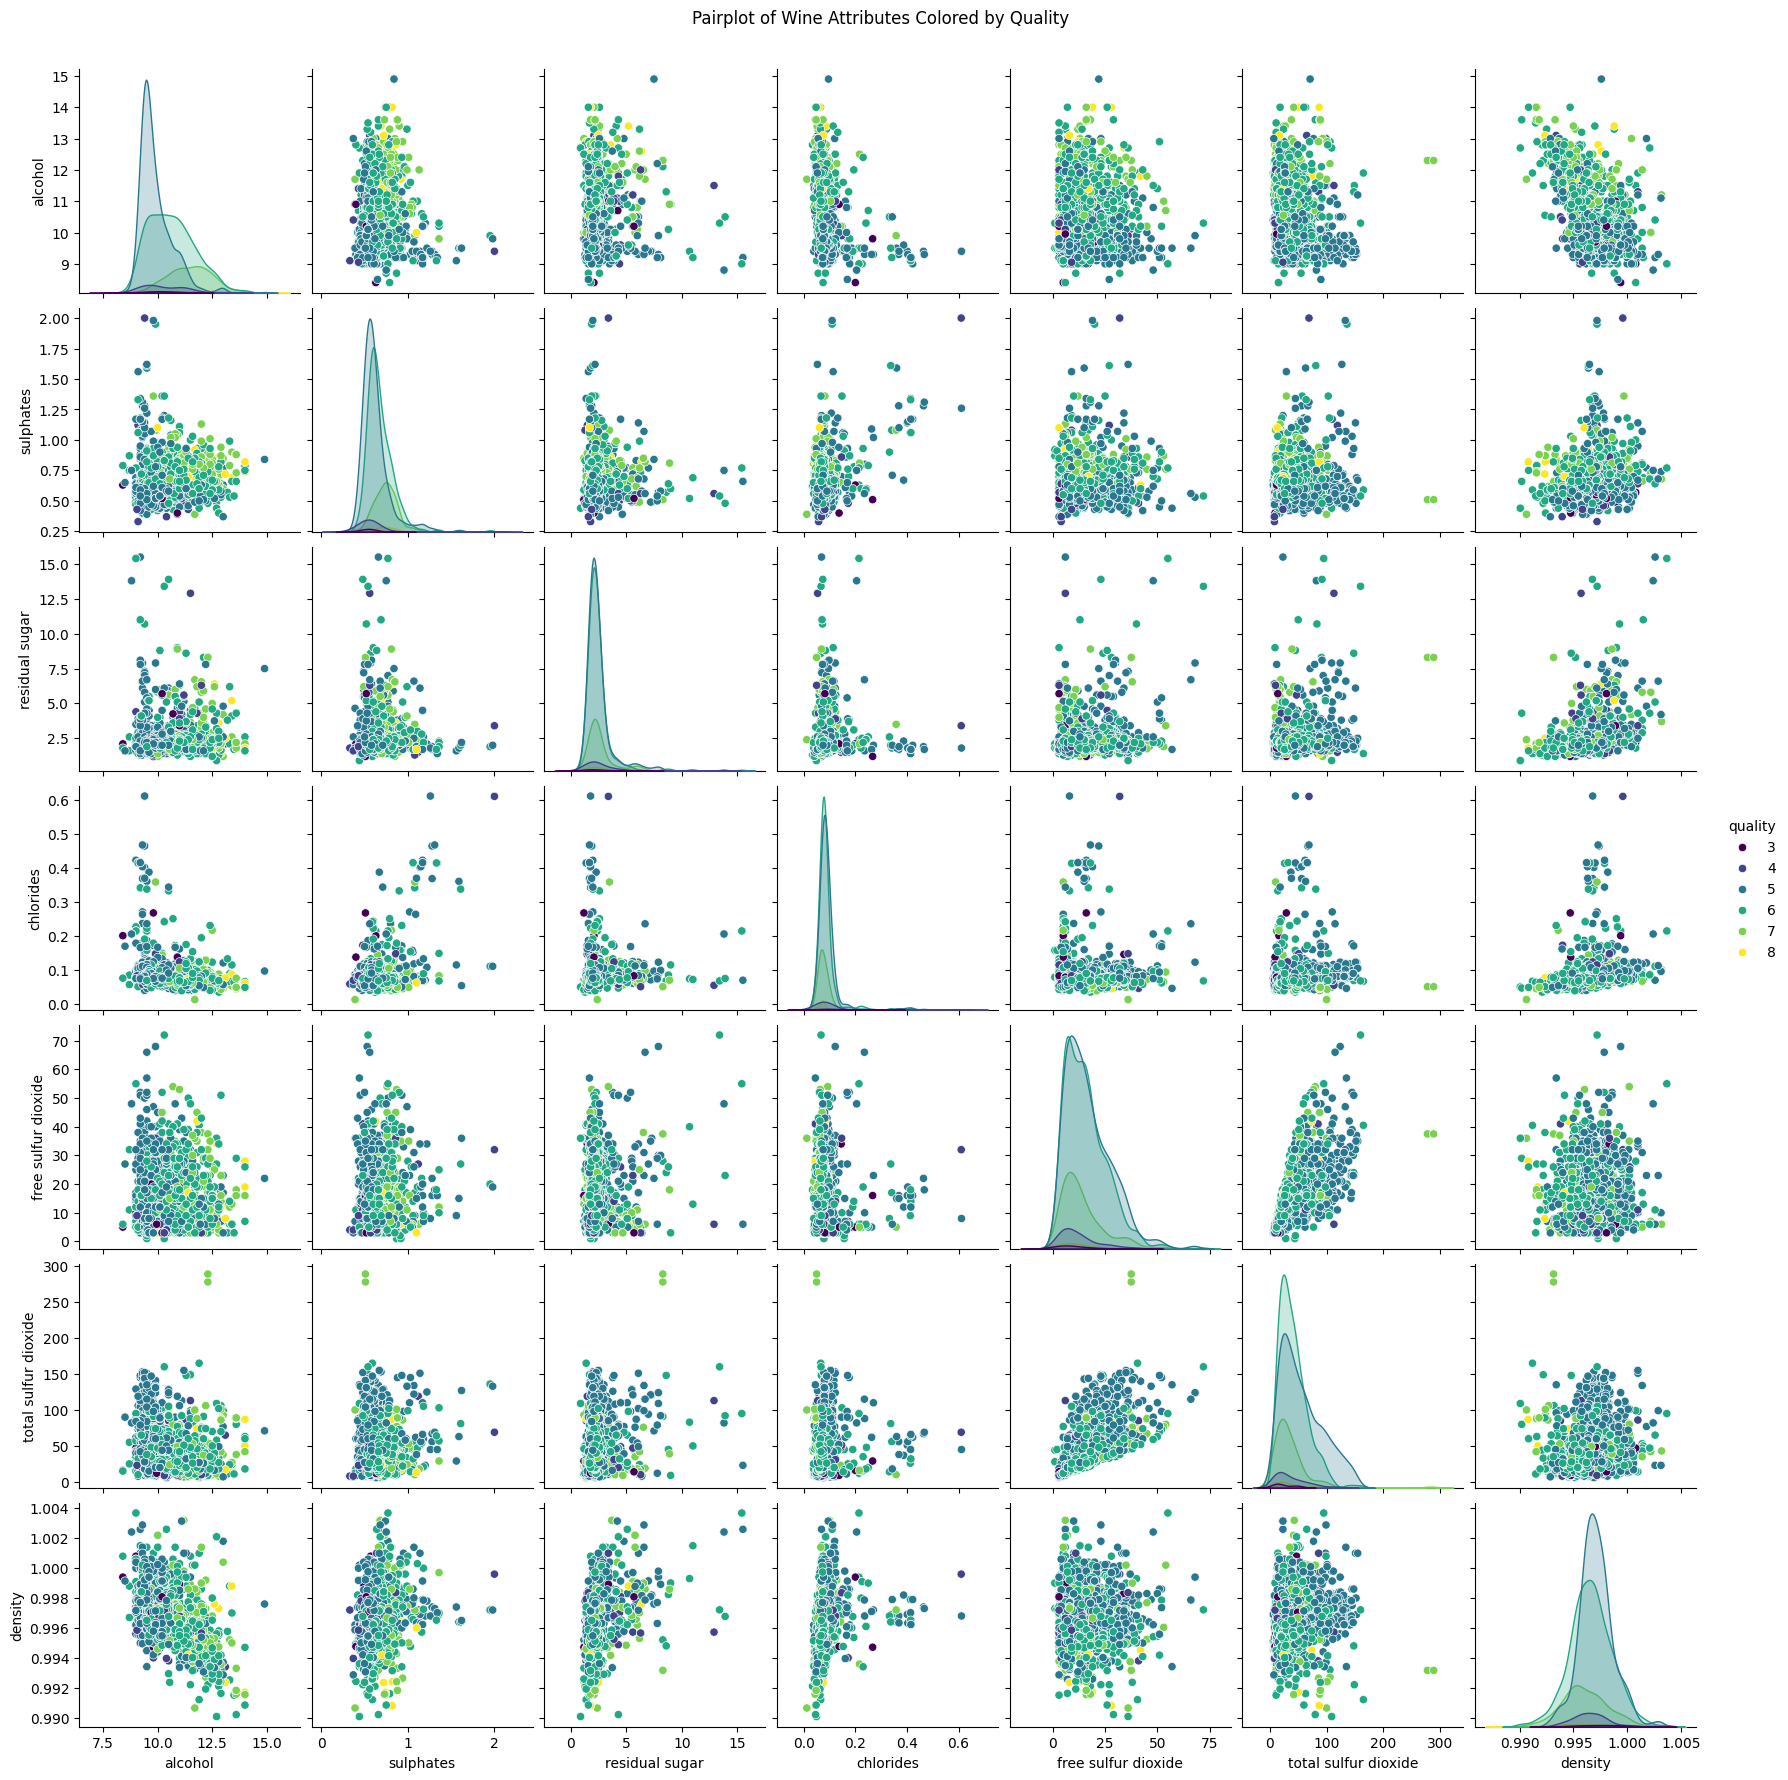

In [ ]:
other_attributes = ['alcohol', 'sulphates', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'quality']

pairplot = sns.pairplot(df[other_attributes], hue='quality', palette='viridis')
pairplot.fig.suptitle('Pairplot of Wine Attributes Colored by Quality', y=1.02)
plt.show()

# 4. Data Preprocessing

In [ ]:
train_dataset, test_dataset =  train_test_split(df, test_size=0.33, random_state=30)

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

1071
528


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=20)
for train_index, test_index in sss.split(df, df['quality']):
    strat_train_dataset = df.loc[train_index]
    strat_test_dataset = df.loc[test_index]

In [ ]:
train_index, test_index = next(sss.split(df, df['quality']))
strat_train_dataset = df.loc[train_index]
strat_test_dataset = df.loc[test_index]

In [ ]:
strat_train_dataset

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
963,8.8,0.270,0.39,2.0,0.100,20.0,27.0,0.99546,3.15,0.69,11.2,6
257,6.6,0.695,0.00,2.1,0.075,12.0,56.0,0.99680,3.49,0.67,9.2,5
686,7.1,0.650,0.18,1.8,0.070,13.0,40.0,0.99700,3.44,0.60,9.1,5
641,9.5,0.590,0.44,2.3,0.071,21.0,68.0,0.99920,3.46,0.63,9.5,5
820,7.0,0.685,0.00,1.9,0.099,9.0,22.0,0.99606,3.34,0.60,9.7,5
...,...,...,...,...,...,...,...,...,...,...,...,...
74,9.7,0.320,0.54,2.5,0.094,28.0,83.0,0.99840,3.28,0.82,9.6,5
112,8.4,0.600,0.10,2.2,0.085,14.0,111.0,0.99640,3.15,0.66,9.8,5
678,8.3,0.780,0.10,2.6,0.081,45.0,87.0,0.99830,3.48,0.53,10.0,5
1419,7.7,0.640,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9,5


In [ ]:
strat_train_dist = strat_train_dataset['quality'].value_counts() / len(strat_train_dataset)
strat_train_dist

quality
5    0.426049
6    0.398823
7    0.124356
4    0.033113
8    0.011038
3    0.006623
Name: count, dtype: float64

In [ ]:
strat_test_dist = strat_test_dataset['quality'].value_counts() / len(strat_test_dataset)
strat_test_dist

quality
5    0.425000
6    0.400000
7    0.125000
4    0.033333
8    0.012500
3    0.004167
Name: count, dtype: float64

## 4.1. Separate features and labels

In [ ]:
features_train = strat_train_dataset.drop('quality', axis=1)
labels_train = strat_train_dataset['quality'].copy()

In [ ]:
features_test = strat_test_dataset.drop('quality', axis=1)
labels_test = strat_test_dataset['quality'].copy()

In [ ]:
features_train.shape

(1359, 11)

In [ ]:
labels_train.shape[0]

1359

In [ ]:
features_test.shape

(240, 11)

In [ ]:
labels_test.shape[0]

240

## 4.2. Normalization

In [ ]:
scaler = StandardScaler()

scaler.fit(features_train)

scaled_features_train = scaler.transform(features_train)

In [ ]:
scaled_features_train

array([[ 0.29765723, -1.43582418,  0.62249779, ..., -1.0642301 ,
         0.17289167,  0.71145778],
       [-0.99005161,  0.92788672, -1.39876088, ...,  1.18690596,
         0.05866718, -1.15247999],
       [-0.69739051,  0.67761145, -0.46587226, ...,  0.85585654,
        -0.34111855, -1.24567688],
       ...,
       [ 0.00499613,  1.4006289 , -0.88048942, ...,  1.12069608,
        -0.74090428, -0.40690488],
       [-0.34619719,  0.62199472, -0.31039083, ..., -0.26971149,
        -1.19780226, -0.50010177],
       [-0.93151939, -2.04760818,  1.91817641, ...,  0.1937577 ,
         0.28711617,  0.71145778]])

In [ ]:
scaler.fit(features_test)

scaled_features_test = scaler.transform(features_test)

In [ ]:
scaled_features_test

array([[ 0.95617498,  0.02365231,  0.99215975, ..., -1.12463165,
        -0.44608055, -1.02792394],
       [ 0.43104455,  1.42845633, -0.0348448 , ..., -0.0189136 ,
         0.15664616,  0.24981419],
       [ 1.58633148, -1.0084486 ,  1.04106473, ...,  0.03928209,
         1.96482628,  0.64296438],
       ...,
       [-0.14659891,  0.65438065, -0.0348448 , ..., -1.06643596,
        -0.22005803, -1.22449904],
       [ 2.1114619 ,  0.19566913,  1.04106473, ..., -1.35741439,
         1.66346293,  0.54467683],
       [-0.67172933,  0.74038906, -1.20856428, ...,  0.15567346,
        -1.95289732, -0.83134885]])

# 5. Model Building & Evaluation

In [ ]:
classification_model = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=2, min_samples_leaf=1),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=2, min_samples_leaf=1),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=1.0),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, weights='uniform'),
    'SGD Classifier': SGDClassifier(loss='hinge', alpha=0.0001, max_iter=1000),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, gamma='scale')
}

In [ ]:
# classification_model = {
#     'Decision Tree': DecisionTreeClassifier(),
#     'Random Forest': RandomForestClassifier(),
#     'Gradient Boosting': GradientBoostingClassifier(),
#     'AdaBoost': AdaBoostClassifier(),
#     'K-Nearest Neigbors': KNeighborsClassifier(),
#     'SGD Classifier': SGDClassifier(),
#     'Support Vector Machine': SVC()
# }

Decision Tree accuracy: 0.59
Random Forest accuracy: 0.60
Gradient Boosting accuracy: 0.59
AdaBoost accuracy: 0.48
K-Nearest Neighbors accuracy: 0.55
SGD Classifier accuracy: 0.47
Support Vector Machine accuracy: 0.59


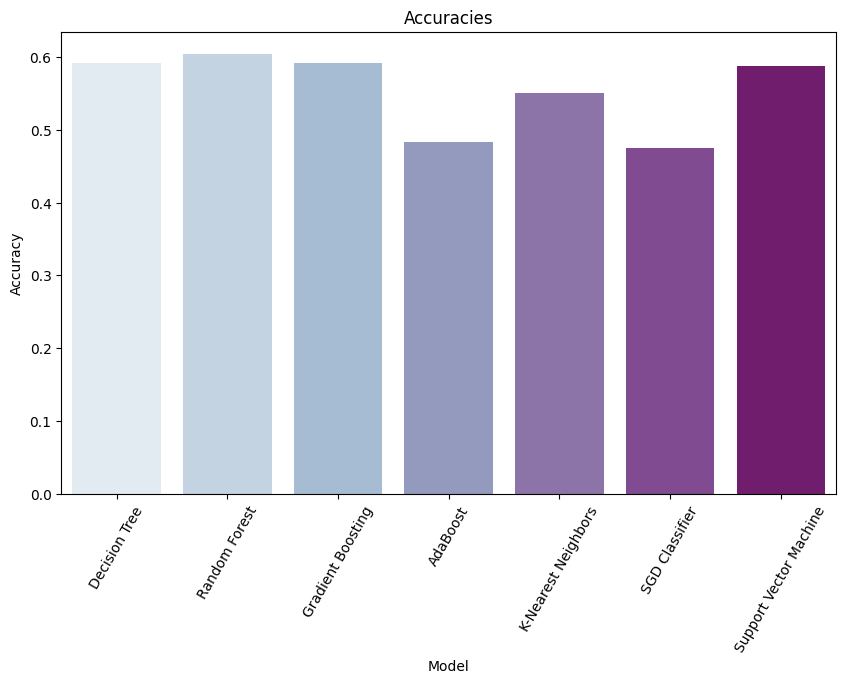

In [ ]:
model_names =  []
accuracies = []

for name, clf in classification_model.items():
    clf.fit(scaled_features_train, labels_train)
    predictions = clf.predict(scaled_features_test)
    score = clf.score(scaled_features_test, labels_test)
    model_names.append(name)
    accuracies.append(score)
    print(f'{name} accuracy: {score:.2f}')


models = pd.DataFrame({'model': model_names, 'accuracy': accuracies})

plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='accuracy', data=models, palette='BuPu')
plt.title('Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=60)
plt.show()